<a href="https://colab.research.google.com/github/Davron030901/Loan-Terms-Assistant/blob/main/train_on_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GOV-01 — Train the Road Damage Classifier (Colab, T4 GPU)

Trains the model for the GOV-01 capstone, then downloads a `model.pt` and
`metadata.json` you commit to `backend/models/` in your repo. Render copies
that directory into the Docker image, so nothing is trained on Render and no
`MODEL_URL` is needed.

**Before you start:** Runtime → Change runtime type → **T4 GPU**. Training on
CPU here would take hours instead of minutes.

**Expected total time:** 25–50 minutes, most of it the dataset download.

---

### One constraint that shapes everything below

GitHub rejects any single file at or above **100 MB**. A fp32 checkpoint is
roughly 4 bytes per parameter:

| Backbone | Params | Checkpoint | Commit to git? | Render free tier? |
|---|---:|---:|---|---|
| `resnet50` | 25.6M | ~102 MB | **No** — over the limit | No, needs ~800 MB RAM |
| `efficientnet_b0` | 5.3M | ~21 MB | Yes | Yes |
| `mobilenet_v3_small` | 2.5M | ~10 MB | Yes | Yes, most headroom |

**Default below is `efficientnet_b0`** — the best accuracy that still fits in
git and in 512 MB of RAM. Train `resnet50` too if you want the comparison for
your report; just deploy the smaller one.


## 1. Check the GPU


In [ ]:
!nvidia-smi

import torch
print()
print('torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU')


Tue Aug  4 12:10:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone your repository

Replace the URL with your own fork. For a private repo, use a personal access
token: `https://<token>@github.com/<you>/<repo>.git`


In [ ]:
import os, shutil

# ACTION REQUIRED: Replace the URL below with your actual fork URL
# If your repo is private, use: https://<your_token>@github.com/user/repo.git
REPO_URL = 'https://github.com/Davron030901/Road-Damage-Image-Classification.git'

if os.path.exists('/content/repo'):
    shutil.rmtree('/content/repo')

# Clone the repo
!git clone --depth 1 $REPO_URL /content/repo

# Change directory to the backend folder where the ml module and requirements reside
if os.path.exists('/content/repo/backend'):
    %cd /content/repo/backend
    !ls
else:
    print('ERROR: /content/repo/backend not found. Check if your REPO_URL is correct and the repo has a backend folder.')

Cloning into '/content/repo'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 79 (delta 0), reused 79 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 130.76 KiB | 8.17 MiB/s, done.
/content/repo/backend
app		   ml	       README.md	      tests
DATA_DISCOVERY.md  models      requirements.txt
Dockerfile	   pytest.ini  TECHNICAL_PROPOSAL.md


## 3. Install dependencies

Colab already ships torch and torchvision built for its GPU — reinstalling
them from `requirements.txt` would replace a working CUDA build with a
mismatched one, so they are filtered out here.


In [ ]:
# Now that the repo is cloned, we can find requirements.txt
!grep -vE '^(torch|torchvision|mlflow)==' requirements.txt > /tmp/colab-reqs.txt
!pip install -q -r /tmp/colab-reqs.txt

import sklearn, PIL, tqdm
print('dependencies ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.8/431.8 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.

## 4. Get the dataset

Pick **one** of the two options below and run only that cell.

### Option A — Kaggle (faster, smaller, binary scope)

A pothole / plain-road classification set. Already foldered by class, so it
needs no conversion. Good if you have chosen the binary damage / no-damage
scope, or if you are short on time.

You need a Kaggle API token: kaggle.com → your profile → Settings → API →
Create New Token. That downloads `kaggle.json`; upload it when prompted.


In [ ]:
# --- OPTION A: Kaggle ---
from google.colab import files
import os, json

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Upload your kaggle.json:')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle

# Search for a current pothole dataset and pick one. Slugs change over time,
# so verify the result rather than trusting a hardcoded name.
!kaggle datasets list -s 'pothole road images' | head -20


ref                                                                  title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
sovitrath/road-pothole-images-for-pothole-detection                  Road Pothole Images for Pothole detection            9466265991  2020-09-17 10:07:25.363000           3008         49  0.8235294        
virenbr11/pothole-and-plain-rode-images                              Pothole and Plain Road Images                         252479613  2019-12-03 13:19:47.233000           3319         33  0.375            
sachinpatel21/pothole-image-dataset                                  Pothole Image Data-Set                                302925020  2019-08-20 09:41:08.597000           9202 

In [ ]:
# Set DATASET_SLUG from the search results above, then run this cell.
DATASET_SLUG = 'atulyakumar98/pothole-detection-dataset'  # <-- verify this exists

!mkdir -p data/raw
!kaggle datasets download -d $DATASET_SLUG -p data/raw --unzip -q

# Inspect what actually landed — folder names become your class labels.
!find data/raw -maxdepth 3 -type d | head -20
!echo '--- image counts per folder ---'
!find data/raw -name '*.jpg' -o -name '*.png' | sed 's|/[^/]*$||' | sort | uniq -c | sort -rn | head


Dataset URL: https://www.kaggle.com/datasets/atulyakumar98/pothole-detection-dataset
License(s): CC0-1.0
data/raw
data/raw/normal
data/raw/potholes
--- image counts per folder ---
    352 data/raw/normal
    329 data/raw/potholes


### Option B — RDD2022 (larger, multi-class, more work)

The dataset described in `DATA_DISCOVERY.md`: ~47,000 images from six
countries with four damage types. It is a *detection* dataset, so
`prepare_data.py` crops each annotated box into a classification sample.

It is several gigabytes. The most reliable route in Colab is to download it
once to your own Google Drive, then mount the Drive here — a fresh download
on every session wastes most of your GPU time.

Read and record the licence before you use it.


In [ ]:
# --- OPTION B: RDD2022 from Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# Adjust to wherever you unpacked RDD2022 in your Drive. The expected layout:
#   <root>/<Country>/train/images/*.jpg
#   <root>/<Country>/train/annotations/xmls/*.xml
RDD_PATH = '/content/drive/MyDrive/datasets/RDD2022'

!ls $RDD_PATH
!echo '--- countries found ---'
!ls $RDD_PATH | head


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ls: cannot access '/content/drive/MyDrive/datasets/RDD2022': No such file or directory
--- countries found ---
ls: cannot access '/content/drive/MyDrive/datasets/RDD2022': No such file or directory


## 5. Prepare the data

This is the step that protects the honesty of your final numbers. It
de-duplicates near-identical images and splits at *group* level, so crops from
one source photo can never land on both sides of the train/test boundary.
See `DATA_DISCOVERY.md` §6.

Run the cell matching the option you chose above.


In [ ]:
# This script generates 'data/processed/classes.json'
!python -m ml.prepare_data --mode folders \
    --source /content/data/raw \
    --out /content/data/processed \
    --min-class-size 50

Reading source (folders) ...
normal: 100% 352/352 [00:00<00:00, 796759.31img/s]
potholes: 100% 329/329 [00:00<00:00, 600490.00img/s]
  681 raw samples
hashing: 100% 681/681 [00:17<00:00, 39.93img/s]
  removed 50 near-duplicates -> 631 samples

Wrote /content/data/processed/manifest.csv (631 samples, 2 classes)
  train     442  {'normal': 213, 'potholes': 229}
  val        95  {'normal': 46, 'potholes': 49}
  test       94  {'normal': 45, 'potholes': 49}

Imbalance ratio (largest class / smallest class): 1.1x


In [ ]:
# For OPTION B (RDD2022):
# !python -m ml.prepare_data --mode rdd2022 \
#     --source $RDD_PATH \
#     --out data/processed \
#     --min-class-size 200


### Read the output before moving on

Check three things in the summary printed above:

1. **Class counts.** If a class vanished, de-duplication may have collapsed it
   — rerun with `--dedup-threshold 2` to be less aggressive.
2. **Imbalance ratio.** Above roughly 20× and the rare classes will be hard to
   learn. Note the figure; it belongs in `DATA_DISCOVERY.md`.
3. **Every class present in val and test.** A class missing from val makes
   macro-F1 undefined for it.


In [ ]:
import json
from pathlib import Path

# The prepare_data script was configured to output to /content/data/processed
info_path = Path('/content/data/processed/classes.json')

if info_path.exists():
    info = json.loads(info_path.read_text())
    print('classes:', info['classes'])
    print()
    for split, counts in info['counts_per_split'].items():
        print(f"{split:<6} {sum(counts.values()):>6}  {counts}")

    missing = [
        (s, c) for s in ('train', 'val', 'test') for c in info['classes']
        if info['counts_per_split'][s].get(c, 0) == 0
    ]
    print()
    print('PROBLEM — class missing from a split:', missing) if missing else print('OK: every class appears in every split')
else:
    print(f'ERROR: {info_path} not found. Check the output of the data preparation cell (zsShKWykoQlb).')

classes: ['normal', 'potholes']

train     442  {'normal': 213, 'potholes': 229}
val        95  {'normal': 46, 'potholes': 49}
test       94  {'normal': 45, 'potholes': 49}

OK: every class appears in every split


## 6. Baseline

A majority-class predictor: the number your real model has to beat. On an
imbalanced dataset it scores deceptively high *accuracy* and very low
*macro-F1*, which is the clearest single demonstration of why macro-F1 is the
metric you selected. **Write this number down for your report.**


In [ ]:
!python -m ml.train --baseline majority --manifest /content/data/processed/manifest.csv

{
  "baseline": "majority_class",
  "majority_class": "potholes",
  "test_macro_f1": 0.3427,
  "test_accuracy": 0.5213,
  "n_test": 94
}


## 7. Train

Two-phase transfer learning: the classification head trains first on a frozen
backbone, then everything unfreezes at a 10× lower learning rate. Selection
and early stopping are on validation macro-F1, never accuracy.

On a T4 this is roughly 20–40 minutes for 15 epochs, depending on dataset
size. If you hit a CUDA out-of-memory error, drop `--batch-size` to 16.


In [ ]:
!python -m ml.train \
    --backbone efficientnet_b0 \
    --epochs 15 \
    --head-epochs 3 \
    --batch-size 32 \
    --device cuda \
    --num-workers 2 \
    --dataset-name 'Pothole Dataset' \
    --manifest /content/data/processed/manifest.csv \
    --out-dir /content/repo/backend/models

Device: cuda | classes: ['normal', 'potholes']
Train distribution: {'normal': 213, 'potholes': 229}
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 152MB/s]
Class weights: {'normal': 1.036, 'potholes': 0.964}
Phase 1 (frozen backbone): 2,562 trainable params
[ 1/18] head     train f1=0.6225 loss=0.6685 | val f1=0.7889 acc=0.7895 loss=0.5976
     saved new best (val macro-F1 0.7889)
[ 2/18] head     train f1=0.8315 loss=0.5576 | val f1=0.8622 acc=0.8632 loss=0.4884
     saved new best (val macro-F1 0.8622)
[ 3/18] head     train f1=0.9059 loss=0.4773 | val f1=0.9153 acc=0.9158 loss=0.4179
     saved new best (val macro-F1 0.9153)
Phase 2 (full fine-tune): 4,010,110 trainable params
[ 4/18] finetune train f1=0.9276 loss=0.4188 | val f1=0.9578 acc=0.9579 loss=0.3431
     saved new best (val macro-F1 0.9578)
[ 5/18] finetune train f1=0.9324 l

### Optional — a second backbone for comparison

The brief lists a transfer-learning comparison as an optional direction, and
it is cheap now that the pipeline exists. Train MobileNetV3 into a *separate*
directory so it does not overwrite your deployment checkpoint.


In [ ]:
!python -m ml.train \
    --backbone mobilenet_v3_small \
    --epochs 15 --batch-size 32 --device cuda --num-workers 2 \
    --out-dir models_mobilenet


Manifest not found: data/processed/manifest.csv. Run ml/prepare_data.py first.


## 8. Evaluate on the held-out test split

This is the only time the test split is touched. Produces per-class metrics, a
confusion matrix, and a list of the most confidently-wrong predictions.


In [ ]:
!python -m ml.evaluate \
    --split test \
    --device cuda \
    --num-workers 2 \
    --manifest /content/data/processed/manifest.csv \
    --checkpoint /content/repo/backend/models/model.pt

eval[test]: 100% 3/3 [00:02<00:00,  1.24it/s]

macro-F1 0.9786 | weighted-F1 0.9787 | accuracy 0.9787
              precision    recall  f1-score   support

      normal       1.00      0.96      0.98        45
    potholes       0.96      1.00      0.98        49

    accuracy                           0.98        94
   macro avg       0.98      0.98      0.98        94
weighted avg       0.98      0.98      0.98        94

Wrote runs/evaluation.json, confusion_matrix.png, misclassified.csv

Now open the top rows of runs/misclassified.csv and write down why each one failed. Those notes go straight into your limitations section.


macro-F1   0.9786   (baseline 0.3427)
accuracy   0.9787

class                  precision   recall      f1      n
normal                     1.000    0.956   0.977     45
potholes                   0.961    1.000   0.980     49


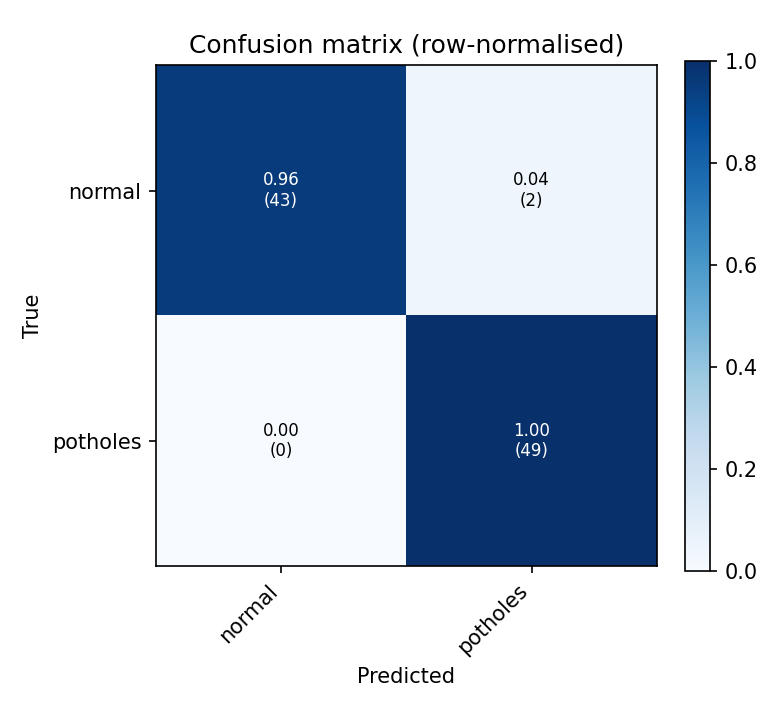

In [ ]:
from IPython.display import Image as ShowImage, display
import json
from pathlib import Path

results_path = Path('/content/repo/backend/runs/evaluation.json')
baseline_path = Path('/content/repo/backend/runs/baseline.json')
cm_path = '/content/repo/backend/runs/confusion_matrix.png'

if results_path.exists() and baseline_path.exists():
    results = json.loads(results_path.read_text())
    baseline = json.loads(baseline_path.read_text())

    print(f"macro-F1   {results['macro_f1']:.4f}   (baseline {baseline['test_macro_f1']:.4f})")
    print(f"accuracy   {results['accuracy']:.4f}")
    print()
    print(f"{'class':<22}{'precision':>10}{'recall':>9}{'f1':>8}{'n':>7}")
    for name, stats in results['per_class'].items():
        print(f"{name:<22}{stats['precision']:>10.3f}{stats['recall']:>9.3f}{stats['f1']:>8.3f}{stats['support']:>7}")

    if Path(cm_path).exists():
        display(ShowImage(cm_path))
else:
    print('ERROR: Evaluation files not found in /content/repo/backend/runs/')
    !ls /content/repo/backend/runs/

### The qualitative error pass — do not skip this

No script can do this part for you, and it is worth more to the client than
another point of F1. The images below are the model's most **confident wrong**
answers. For a triage tool those are the dangerous ones: a confidently wrong
result is the one a human reviewer is least likely to question.

Look at each one and write down *why* it failed — blur, odd angle, shadow
mistaken for a crack, something that is not a road. Those notes become the
limitations section of your report.


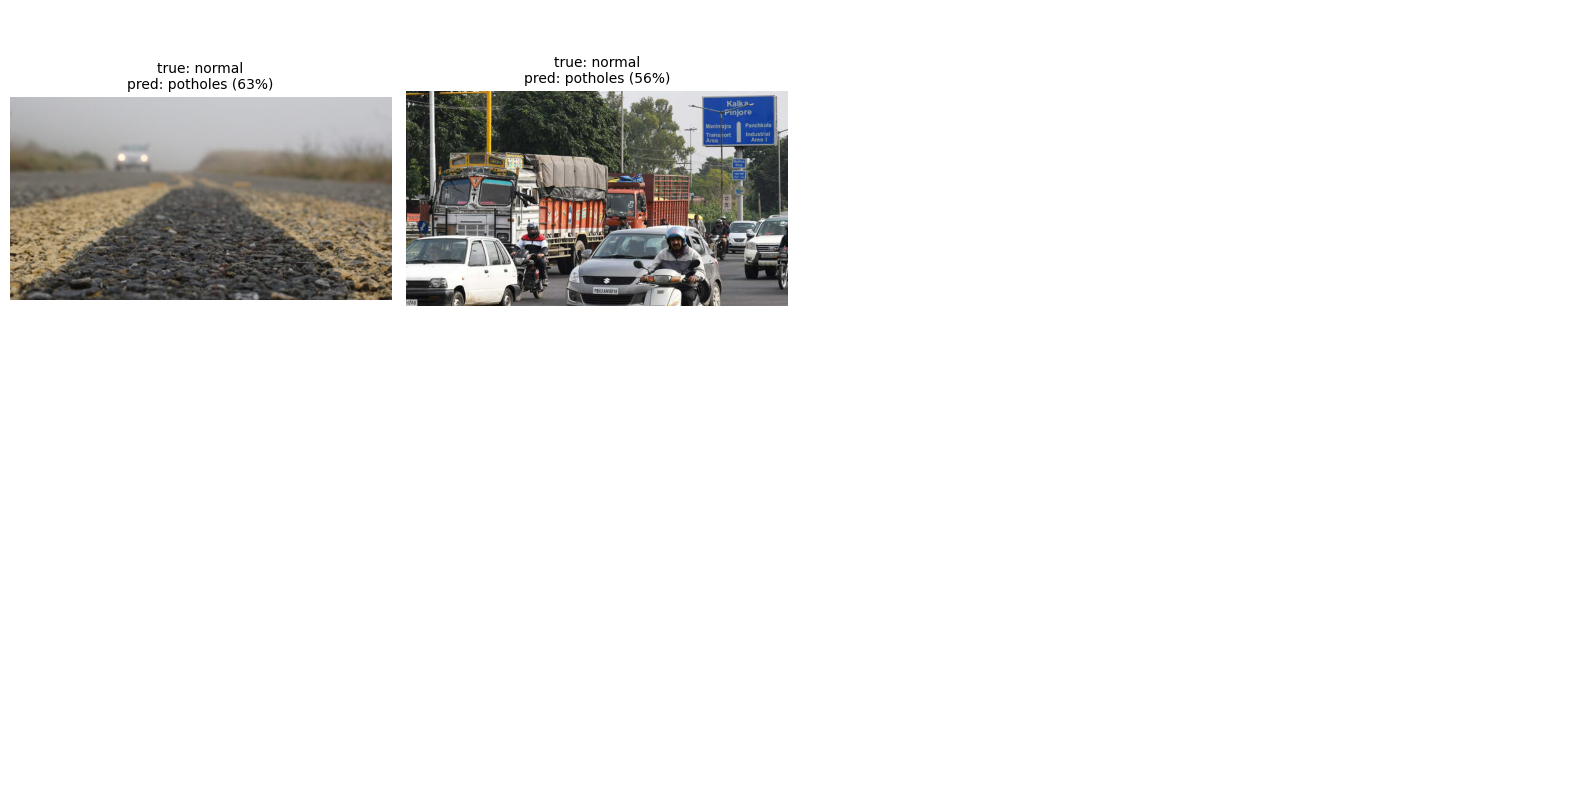

In [ ]:
import csv
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

csv_path = '/content/repo/backend/runs/misclassified.csv'

if Path(csv_path).exists():
    with open(csv_path) as fh:
        errors = list(csv.DictReader(fh))[:8]

    if errors:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        for ax, err in zip(axes.flat, errors):
            img_path = Path('/content/repo/backend') / err['path']
            if img_path.exists():
                ax.imshow(Image.open(img_path))
                ax.set_title(f"true: {err['true']}\npred: {err['predicted']} ({float(err['confidence']):.0%})", fontsize=10)
            ax.axis('off')
        for ax in axes.flat[len(errors):]:
            ax.axis('off')
        plt.tight_layout(); plt.show()
    else:
        print('No misclassifications on the test split.')
else:
    print(f'File not found: {csv_path}')

## 9. Check the checkpoint is deployable

Verifies three things that otherwise only surface after a failed deploy: the
file fits GitHub's 100 MB limit, it loads on a CPU-only host, and
`metadata.json` agrees with the checkpoint.


In [ ]:
!python -m ml.check_deploy --models-dir models


/usr/bin/python3: No module named ml.check_deploy


## 10. Download the artefacts

Two files. Both go into `backend/models/` in your repo.


In [ ]:
from google.colab import files
import json, shutil
from pathlib import Path

model_path = Path('/content/repo/backend/models/model.pt')
meta_path = Path('/content/repo/backend/models/metadata.json')

if model_path.exists() and meta_path.exists():
    print('metadata.json:')
    print(json.dumps(json.loads(meta_path.read_text()), indent=2))
    print()
    print(f"model.pt: {model_path.stat().st_size / 1e6:.1f} MB")

    files.download(str(model_path))
    files.download(str(meta_path))
else:
    print('Models not found in /content/repo/backend/models/')
    !ls /content/repo/backend/models/

metadata.json:
{
  "model_version": "1.0.0+20260804-121452",
  "backbone": "efficientnet_b0",
  "classes": [
    "normal",
    "potholes"
  ],
  "input_size": 224,
  "trained_at": "2026-08-04T12:16:59+00:00",
  "dataset": "Pothole Dataset",
  "primary_metric": "macro_f1",
  "primary_metric_value": 1.0,
  "best_epoch": 6,
  "seed": 42,
  "class_weights_used": true,
  "pretrained": true,
  "train_distribution": {
    "normal": 213,
    "potholes": 229
  },
  "framework": {
    "torch": "2.11.0+cu128",
    "python": "3.12.13"
  },
  "notes": "Validation macro-F1. Test-set numbers are produced separately by ml/evaluate.py and recorded in runs/evaluation.json."
}

model.pt: 16.3 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Also save your evaluation output

`evaluation.json` and `confusion_matrix.png` are report material — the Colab
runtime is deleted when the session ends.


In [ ]:
import shutil
from google.colab import files

# Zip the runs folder from the correct location
shutil.make_archive('/content/evaluation-output', 'zip', '/content/repo/backend/runs')
files.download('/content/evaluation-output.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Commit and deploy

On your own machine, in the repo:

```bash
# Put the two downloaded files into backend/models/
cp ~/Downloads/model.pt      backend/models/
cp ~/Downloads/metadata.json backend/models/

# Verify once more locally
cd backend && python -m ml.check_deploy && cd ..

git add backend/models/model.pt backend/models/metadata.json
git commit -m 'Add trained model (efficientnet_b0)'
git push
```

`.gitignore` deliberately allows `backend/models/model.pt` through while
excluding every other `.pt`, so your comparison runs stay out of the repo.

Render rebuilds on push. The Dockerfile copies `backend/models/`, so the
checkpoint ships inside the image.

**Then, in the Render dashboard:** delete the `MODEL_URL` environment
variable entirely, or set it to an empty string. If it holds a stale or
invalid value the service tries to download over the model you just shipped.

Confirm:

```bash
curl https://<your-service>.onrender.com/api/v1/health
# {"status":"ok","model_loaded":true,"model_version":"1.0.0+...","demo_mode":false}
```

See `DEPLOY.md` for the full checklist.
